Method              Time(s)        Updates             Final Loss     
Batch GD            0.1675         30                  1.682565       
SGD                 5.4804         495360              790095517064527266531085851240807030125937945181787249179559472135409595004573121006461492363570517687592697960318806774641084420186933074200108137049330645447558463349770338801798534485705690064581056198456382423749654758432113761017785336670381529683811782282187705942016.000000
Mini Batch (64)     0.1303         7740                0.259655       


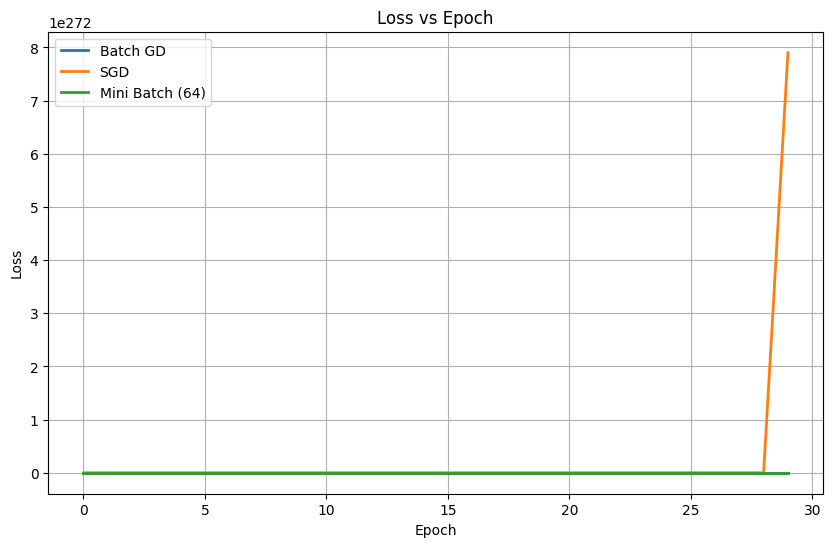

In [ ]:
# ==============================
# Gradient Descent Comparison
# Batch GD vs SGD vs Mini-Batch GD
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Load Dataset
# ----------------------------
housing = fetch_california_housing()

X = housing.data
y = housing.target.reshape(-1,1)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Add Bias Term
X_train = np.c_[np.ones((X_train.shape[0],1)), X_train]

# ----------------------------
# Cost Function
# ----------------------------
def compute_loss(X,y,w):
    m = len(y)
    pred = X @ w
    return np.sum((pred-y)**2)/(2*m)

# ----------------------------
# Gradient Descent Function
# ----------------------------
def gradient_descent(X,y,learning_rate=0.01,
                     epochs=30,batch_size=None):

    m,n = X.shape
    w = np.zeros((n,1))

    losses=[]
    updates=0

    start=time.time()

    for epoch in range(epochs):

        if batch_size is None:
            batch_size=m

        indices=np.random.permutation(m)
        X_shuffled=X[indices]
        y_shuffled=y[indices]

        for i in range(0,m,batch_size):

            X_batch=X_shuffled[i:i+batch_size]
            y_batch=y_shuffled[i:i+batch_size]

            predictions=X_batch@w

            gradient=(X_batch.T@(predictions-y_batch))/len(y_batch)

            w=w-learning_rate*gradient

            updates+=1

        losses.append(compute_loss(X,y,w))

    end=time.time()

    return w,losses,end-start,updates

# ----------------------------
# Run Batch GD
# ----------------------------
w_batch,loss_batch,time_batch,updates_batch=gradient_descent(
    X_train,y_train,
    learning_rate=0.01,
    epochs=30,
    batch_size=len(X_train)
)

# ----------------------------
# Run SGD
# ----------------------------
w_sgd,loss_sgd,time_sgd,updates_sgd=gradient_descent(
    X_train,y_train,
    learning_rate=0.01,
    epochs=30,
    batch_size=1
)

# ----------------------------
# Run Mini Batch GD (64)
# ----------------------------
w_mini,loss_mini,time_mini,updates_mini=gradient_descent(
    X_train,y_train,
    learning_rate=0.01,
    epochs=30,
    batch_size=64
)

# ----------------------------
# Results
# ----------------------------
print("="*60)
print("{:<20}{:<15}{:<20}{:<15}".format(
    "Method","Time(s)","Updates","Final Loss"))
print("="*60)

print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format(
    "Batch GD",time_batch,updates_batch,loss_batch[-1]))

print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format(
    "SGD",time_sgd,updates_sgd,loss_sgd[-1]))

print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format(
    "Mini Batch (64)",time_mini,updates_mini,loss_mini[-1]))

# ----------------------------
# Plot Loss Curves
# ----------------------------
plt.figure(figsize=(10,6))

plt.plot(loss_batch,label="Batch GD",linewidth=2)
plt.plot(loss_sgd,label="SGD",linewidth=2)
plt.plot(loss_mini,label="Mini Batch (64)",linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()



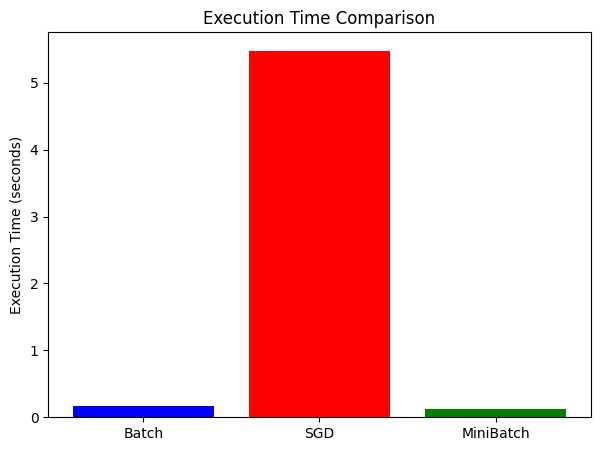

In [ ]:
# ----------------------------
# Bar Chart - Execution Time
# ----------------------------
methods=["Batch","SGD","MiniBatch"]

times=[time_batch,time_sgd,time_mini]

plt.figure(figsize=(7,5))
plt.bar(methods,times,color=["blue","red","green"])
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")
plt.show()


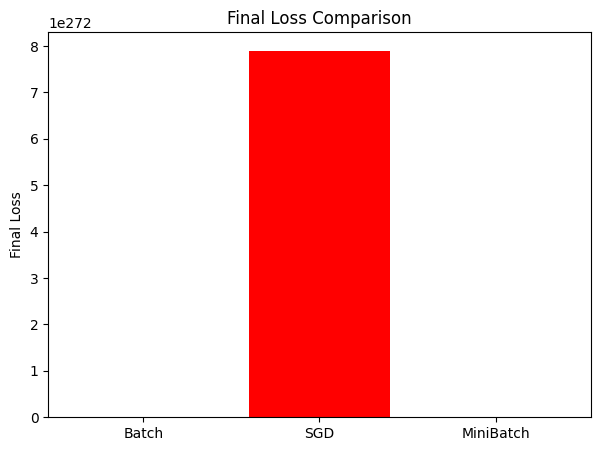

In [ ]:

# ----------------------------
# Bar Chart - Final Loss
# ----------------------------
losses=[loss_batch[-1],loss_sgd[-1],loss_mini[-1]]

plt.figure(figsize=(7,5))
plt.bar(methods,losses,color=["blue","red","green"])
plt.ylabel("Final Loss")
plt.title("Final Loss Comparison")
plt.show()

Method              Time(s)        Updates             Final Loss     
Batch GD            0.0189         50                  1524.245646    
SGD                 0.9088         17650               2080.512193    
Mini Batch (32)     0.0537         600                 1486.876433    


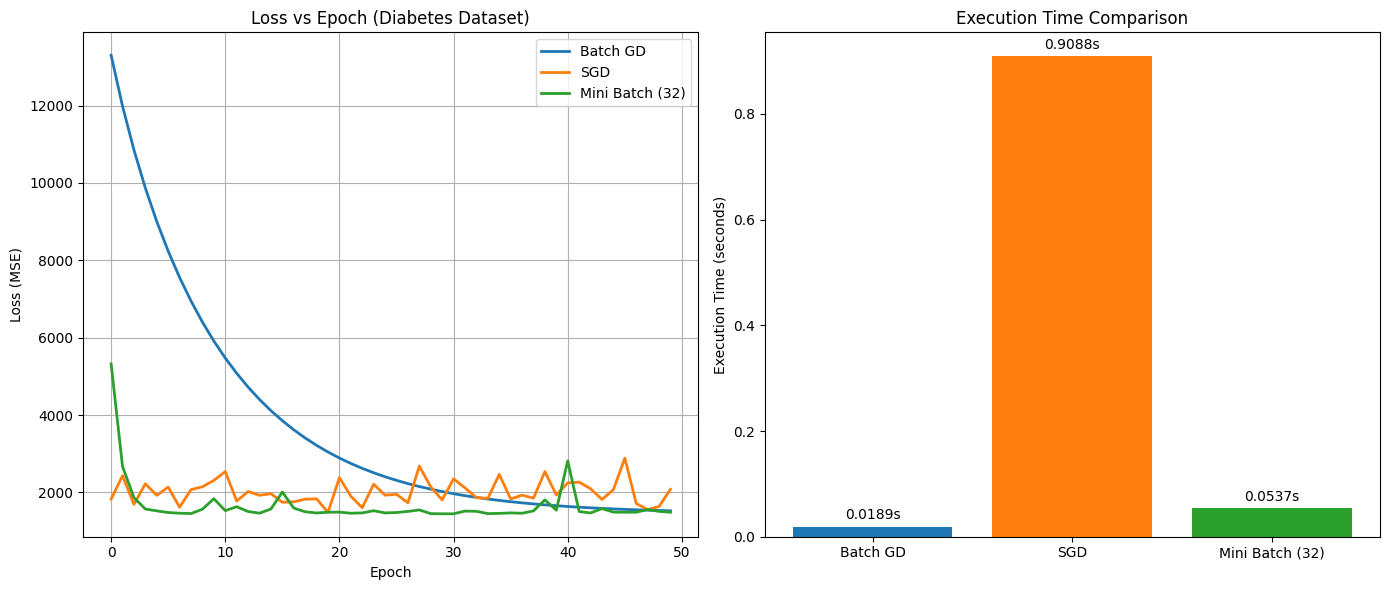

In [ ]:
# ==============================
# Gradient Descent Comparison
# Batch GD vs SGD vs Mini-Batch GD
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------
# Load Dataset (Diabetes)
# ----------------------------
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target.reshape(-1, 1)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# Add Bias Term
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]

# ----------------------------
# Cost Function
# ----------------------------
def compute_loss(X, y, w):
    m = len(y)
    pred = X @ w
    return np.sum((pred - y)**2) / (2 * m)

# ----------------------------
# Gradient Descent Function
# ----------------------------
def gradient_descent(X, y, learning_rate=0.01, epochs=30, batch_size=None):
    m, n = X.shape
    w = np.zeros((n, 1))
    losses = []
    updates = 0
    start = time.time()

    for epoch in range(epochs):
        if batch_size is None:
            batch_size = m

        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            predictions = X_batch @ w
            gradient = (X_batch.T @ (predictions - y_batch)) / len(y_batch)
            w = w - learning_rate * gradient
            updates += 1

        losses.append(compute_loss(X, y, w))

    end = time.time()
    return w, losses, end - start, updates

# ----------------------------
# Run Variants
# ----------------------------
# Adjusted learning rate and epochs for the diabetes dataset characteristics
w_batch, loss_batch, time_batch, updates_batch = gradient_descent(
    X_train, y_train, learning_rate=0.05, epochs=50, batch_size=len(X_train)
)

w_sgd, loss_sgd, time_sgd, updates_sgd = gradient_descent(
    X_train, y_train, learning_rate=0.05, epochs=50, batch_size=1
)

w_mini, loss_mini, time_mini, updates_mini = gradient_descent(
    X_train, y_train, learning_rate=0.05, epochs=50, batch_size=32
)

# ----------------------------
# Results
# ----------------------------
print("="*60)
print("{:<20}{:<15}{:<20}{:<15}".format("Method", "Time(s)", "Updates", "Final Loss"))
print("="*60)
print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format("Batch GD", time_batch, updates_batch, loss_batch[-1]))
print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format("SGD", time_sgd, updates_sgd, loss_sgd[-1]))
print("{:<20}{:<15.4f}{:<20}{:<15.6f}".format("Mini Batch (32)", time_mini, updates_mini, loss_mini[-1]))

# ----------------------------
# Plotting Loss Curves & Time
# ----------------------------
plt.figure(figsize=(14, 6))

# Subplot 1: Loss vs Epochs
plt.subplot(1, 2, 1)
plt.plot(loss_batch, label="Batch GD", linewidth=2)
plt.plot(loss_sgd, label="SGD", linewidth=2)
plt.plot(loss_mini, label="Mini Batch (32)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epoch (Diabetes Dataset)")
plt.legend()
plt.grid(True)

# Subplot 2: Time Comparison Bar Chart
plt.subplot(1, 2, 2)
methods = ['Batch GD', 'SGD', 'Mini Batch (32)']
times = [time_batch, time_sgd, time_mini]
bars = plt.bar(methods, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")

# Add text labels on bars for precise time reading
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.01), f'{yval:.4f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# a. Load and preprocess dataset
# ==========================================
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==========================================
# b. Design NN (Function to create a fresh model)
# ==========================================
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),          # Input layer (flattens 28x28 images to 784 1D array)
        Dense(128, activation='relu'),          # 1 Hidden layer using ReLU
        Dense(10, activation='softmax')         # Output layer (10 neurons, Softmax function)
    ])
    return model

# ==========================================
# d. Train the model separately using SGD(momentum), Adagrad, RMSprop, and Adam
# ==========================================
# Keep all hyperparameters the same
LEARNING_RATE = 0.001
EPOCHS = 10
BATCH_SIZE = 64

# Define the optimizers
optimizers = {
    'SGD with Momentum': tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.9),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=LEARNING_RATE),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
    'Adam': tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
}

# Dictionary to store the history of each model for plotting later
history_dict = {}

for opt_name, optimizer in optimizers.items():
    print(f"\n--- Training with {opt_name} ---")

    # Create a fresh model for each optimizer
    model = create_model()

    # Compile the model
    # Note: sparse_categorical_crossentropy is used because labels are integers (0-9), not one-hot encoded
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(x_train, y_train,
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_data=(x_test, y_test),
                        verbose=1)

    # Save the history
    history_dict[opt_name] = history.history

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training with SGD with Momentum ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7760 - loss: 0.8976 - val_accuracy: 0.8834 - val_loss: 0.4616
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8875 - loss: 0.4209 - val_accuracy: 0.9022 - val_loss: 0.3574
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9007 - loss: 0.3549 - val_accuracy: 0.9125 - val_loss: 0.3178
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9089 - loss: 0.3218 - val_accuracy: 0.9186 - val_loss: 0.2949
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9147 - loss: 0.2992 - val_accuracy: 0.9218 - val_loss: 0.2781
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9196 - loss: 0.2817 - val_accuracy: 0.9257 - val_loss: 0.2634
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9243 - loss: 0.2671 - val_accuracy: 0.9305 - val_loss: 0.2509
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9285 - loss: 0.2542 - val_accuracy: 0.

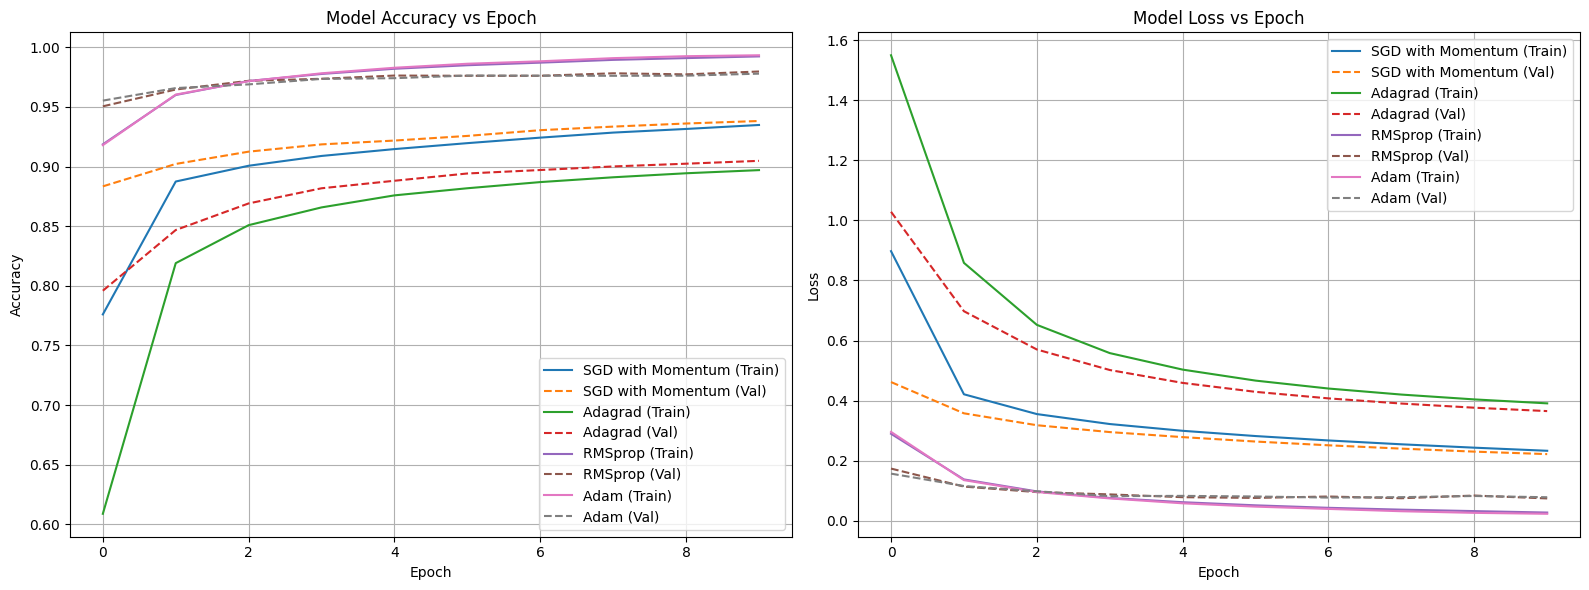

In [ ]:
# ==========================================
# e & f. Compare metrics and Plot acc/loss vs epoch
# ==========================================
plt.figure(figsize=(16, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
for opt_name, history in history_dict.items():
    plt.plot(history['accuracy'], label=f"{opt_name} (Train)")
    plt.plot(history['val_accuracy'], linestyle='--', label=f"{opt_name} (Val)")
plt.title('Model Accuracy vs Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
for opt_name, history in history_dict.items():
    plt.plot(history['loss'], label=f"{opt_name} (Train)")
    plt.plot(history['val_loss'], linestyle='--', label=f"{opt_name} (Val)")
plt.title('Model Loss vs Epoch')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

"""
IDENTIFICATION AND JUSTIFICATION:

Fastest Converging Optimizer: Adam (closely followed by RMSprop)

Justification:
Adam (Adaptive Moment Estimation) generally converges the fastest in this setup.
This is because it combines the best properties of both RMSprop and SGD with momentum:
1. Like RMSprop, it keeps an exponentially decaying average of past squared gradients,
   which adapts the learning rate for each parameter individually (helpful for sparse data).
2. Like SGD with momentum, it keeps an exponentially decaying average of past gradients
   (first moment), which helps it power through noisy gradients and local minima.

Because we kept the learning rate fixed at 0.001 across all optimizers (as requested),
you will likely see Adagrad and standard SGD perform quite poorly or slowly in the plots.
0.001 is the default/ideal starting rate for Adam, but it is typically too small for
Adagrad or standard SGD to make rapid progress in the early epochs.
"""